# Statistical Correlation Matrix Heatmap

Correlation matrix heatmaps visualize the linear relationships (Pearson correlation coefficients) between multiple continuous numerical columns. Finding highly correlated variables is a crucial step in exploratory data analysis and feature engineering. This notebook generates synthetic variables with embedded correlations and plots the correlation matrix as a styled Seaborn heatmap.



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate correlated synthetic features (500 samples, 6 columns)
np.random.seed(88)
n_samples = 500

# Base independent features
feat_1 = np.random.normal(10, 2, n_samples)
feat_2 = np.random.normal(50, 10, n_samples)
feat_3 = np.random.normal(0, 1, n_samples)

# Dependent correlated features
feat_4 = 0.8 * feat_1 + np.random.normal(0, 0.5, n_samples) # Strong positive correlation with feat_1
feat_5 = -0.75 * feat_2 + np.random.normal(0, 3.0, n_samples) # Strong negative correlation with feat_2
feat_6 = 0.3 * feat_1 - 0.4 * feat_3 + np.random.normal(0, 0.2, n_samples)

df_corr = pd.DataFrame({
    'Income': feat_1,
    'Age': feat_2,
    'Education_Yrs': feat_3,
    'Savings': feat_4,
    'Debt': feat_5,
    'Spending_Score': feat_6
})

df_corr.head(10)



,Income,Age,Education_Yrs,Savings,Debt,Spending_Score
0,10.213769,37.034933,1.049742,8.693878,-25.416302,2.348828
1,14.411630,58.278137,0.347022,10.588575,-44.739595,4.167527
2,11.913125,53.134734,0.884287,10.822663,-43.007254,3.383044
3,10.136822,46.276826,1.229877,7.988685,-31.072023,2.547902
4,12.137028,61.024653,0.289740,9.689047,-48.737924,3.654565
5,11.994365,56.675470,0.040918,9.946798,-36.405861,3.569319
6,8.136904,48.308790,-0.082505,6.786877,-33.358736,2.764665
7,11.460861,64.049534,-0.307353,9.178830,-45.845965,3.611129
8,9.657573,53.895561,0.978967,7.885986,-41.458006,2.524840
9,7.422618,56.553212,0.456662,5.477583,-43.167570,2.487245


## Pearson Correlation Matrix Calculation

We calculate the symmetric Pearson correlation coefficients matrix across all features.



In [2]:
corr_matrix = df_corr.corr()
print("Pearson Correlation Coefficients Matrix:")
corr_matrix



Pearson Correlation Coefficients Matrix:


,Income,Age,Education_Yrs,Savings,Debt,Spending_Score
Income,1.000000,-0.024324,0.024745,0.959503,0.013823,0.781985
Age,-0.024324,1.000000,0.012308,-0.030271,-0.928097,-0.020435
Education_Yrs,0.024745,0.012308,1.000000,0.029438,-0.010721,-0.546210
Savings,0.959503,-0.030271,0.029438,1.000000,0.021162,0.749597
Debt,0.013823,-0.928097,-0.010721,0.021162,1.000000,0.016454
Spending_Score,0.781985,-0.020435,-0.546210,0.749597,0.016454,1.000000


## Styled Seaborn Correlation Heatmap

Using Seaborn, we visualize the matrix as an annotated heatmap, using a diverging palette and adding a mask to hide the redundant upper triangle.



<cell>:21: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



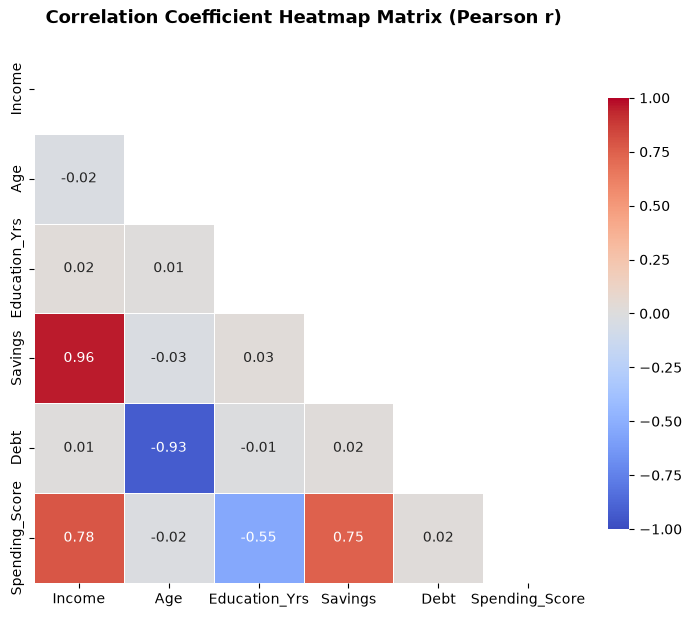

In [3]:
plt.figure(figsize=(9, 7))

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw correlation heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1.0, 
    vmax=1.0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Coefficient Heatmap Matrix (Pearson r)', fontsize=13, fontweight='bold', pad=15)
plt.show()
